# Data Transformations

note :
This notebook includes additional images, screenshots, diagrams, and explanatory notes in some sections to support my understanding of the concepts.

 I incorporated these materials as part of my learning process and to create useful study notes for future reference.

 The primary objective was to understand the concepts thoroughly while completing the assignment.


In [42]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler,StandardScaler # used for the  preprocessing of the data
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv('/content/adult_with_headers (1).csv')

In [44]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [45]:
df.shape

(32561, 15)

In [46]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [48]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [49]:
# for better understanding and remenber the point that what we see zeros in the sum of null values,
# and the data also has loop hole such as stroing 0's and nan's and etc
# we should find and replace them if needed and remove them in case of not needed
missing_values = ["", " ", "NaN", "nan", "NULL", "null", "None", "none", "?"]

for value in missing_values:
    print(f"\nChecking for '{value}'")
    print((df.astype(str) == value).sum())


Checking for ''
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Checking for ' '
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Checking for 'NaN'
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Check

In [50]:
(df == " ?").sum() # shows how check for the over all data we have loaded


,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [51]:
df.replace(" ?", np.nan, inplace=True)

df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [52]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_933/3842376714.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [53]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [54]:
duplicate_count = df.duplicated().sum()

In [55]:
duplicate_count

np.int64(24)

In [56]:
total_rows = len(df)

In [57]:
total_rows

32561

In [58]:
# the main purpose of doing this to find how much amount of duplicate data is there in our data in terms of percentage
# it is less percentage so we can remove them if it has more percentage of date we need to replace them with certain values
duplicate_percentage = (duplicate_count / total_rows) *100
duplicate_percentage

np.float64(0.07370780995669667)

In [59]:
df = df.drop_duplicates()


In [60]:
# we have removed the duplicate rows
df.duplicated().sum()

np.int64(0)

The dataset was examined for duplicate records using the duplicated() function.

 A total of 24 duplicate rows were identified, representing 0.0737% of the dataset.

  These duplicate records were removed using drop_duplicates() to improve data quality and avoid bias during analysis.

In [61]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns
# it is just like using df.columns which prints all the columns but in between we are selecting datatypes by giving this command select_dtypes(include=["int64","float64"])
numerical_columns

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [62]:
standard_scaler = StandardScaler()


In [63]:
df_standard = df.copy() # we used the copy method to show that how the original and scaled vlaues differ

In [64]:
df_standard[numerical_columns] = standard_scaler.fit_transform(df_standard[numerical_columns])

In [65]:
df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,State-gov,-1.063569,Bachelors,1.134777,Never-married,Adm-clerical,Not-in-family,White,Male,0.148292,-0.216743,-0.035664,United-States,<=50K
1,0.836973,Self-emp-not-inc,-1.008668,Bachelors,1.134777,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145975,-0.216743,-2.222483,United-States,<=50K
2,-0.042936,Private,0.245040,HS-grad,-0.420679,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
3,1.056950,Private,0.425752,11th,-1.198407,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
4,-0.776193,Private,1.408066,Bachelors,1.134777,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145975,-0.216743,-0.035664,Cuba,<=50K


In [66]:
minmax_scaler = MinMaxScaler()

In [67]:
df_standard[numerical_columns] = minmax_scaler.fit_transform(df[numerical_columns]) # minmax scaling

In [68]:
df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


**Interpretation**

####Standard Scaling

Mean becomes 0.

Standard deviation becomes 1.

Best for algorithms like Logistic Regression, SVM, KNN.

####Min-Max Scaling

Converts values between 0 and 1.

Best for Neural Networks and Deep Learning.

Keeps original distribution.

In [69]:
for x in "python" : # we can consider this as an basic example of the code we use itreration
  print(x)

p
y
t
h
o
n


📝 Label Encoding → One column, categories become numbers.

📦 One-Hot Encoding → Many columns, one column per category.

📊 Ordinal Encoding → One column, but you define the order (e.g., Small < Medium < Large).

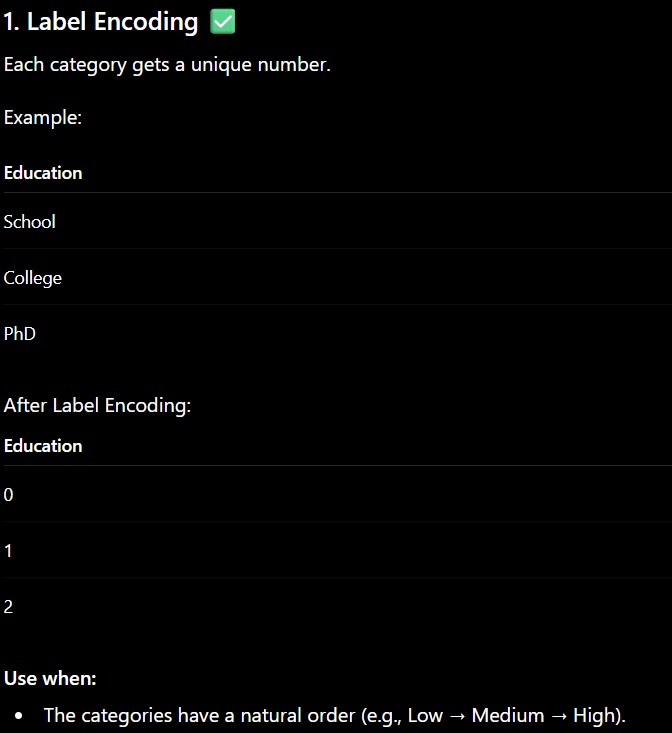

In [70]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_encoded = df.copy()

# Create LabelEncoder object
label_encoder = LabelEncoder()

# Find all categorical columns and you can see that we used this step in the previous scaling techniques
categorical_columns = df_encoded.select_dtypes(include='object').columns

# Apply Label Encoding to each categorical column
for column in categorical_columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# Display the first few rows
df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0


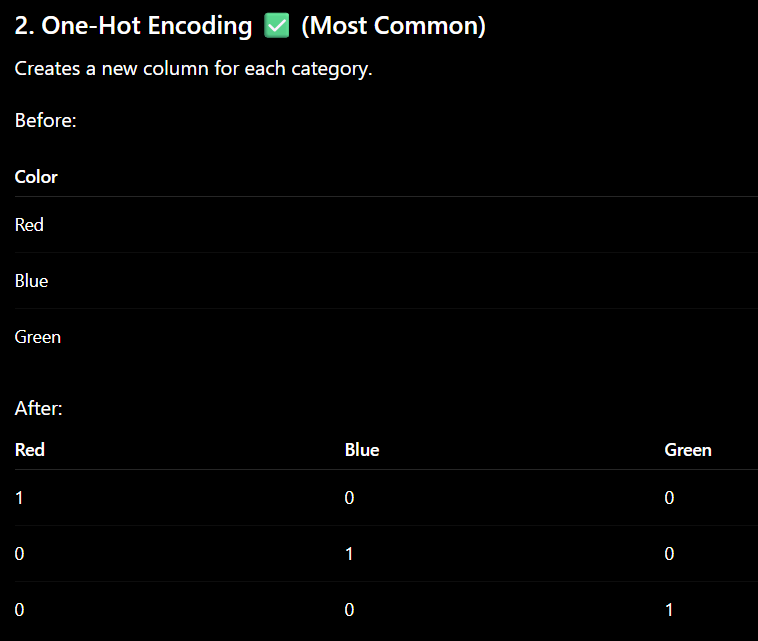

In [71]:
import pandas as pd

# Create a copy of the dataset
df_onehot = df.copy()

# Find all categorical columns
categorical_columns = df_onehot.select_dtypes(include='object').columns

# Apply One-Hot Encoding
df_onehot = pd.get_dummies(df_onehot, # this is just like passing data in the visualisations
                           columns=categorical_columns,# and for refernce we can take it as column assigning
                           drop_first=True)

# Display the first few rows
df_onehot.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,...,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia,income_ >50K
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,38,215646,9,0,0,40,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,53,234721,7,0,0,40,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,28,338409,13,0,0,40,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


featutre engineering is nothing but creatinng an useful feature from the data which they have given

you can see the following features which are created


In [72]:
# Combines total financial gain into one feature
df["capital_total"] = df["capital_gain"] - df["capital_loss"]


capital_total:

Combines capital gain and capital loss into one feature to represent overall financial performance.

In [73]:
df[['capital_total']]

,capital_total
0,2174
1,0
2,0
3,0
4,0
...,...
32556,0
32557,0
32558,0
32559,0


In [74]:
# Represents overall work effort considering age and working hours
df["work_intensity"] = df["age"] * df["hours_per_week"]

work_intensity:

Combines age and weekly working hours to estimate the overall working effort of an individual.

In [75]:
df[numerical_columns].skew()

,0
age,0.557663
fnlwgt,1.447703
education_num,-0.309500
capital_gain,11.949403
capital_loss,4.592702
hours_per_week,0.228759


The capital_gain feature is highly right-skewed because many values are zero while a few are extremely large.

 Applying a log transformation reduces skewness, minimizes the influence of outliers, and creates a more balanced distribution for machine learning models.

In [76]:
df["capital_gain_log"] = np.log1p(df["capital_gain"])

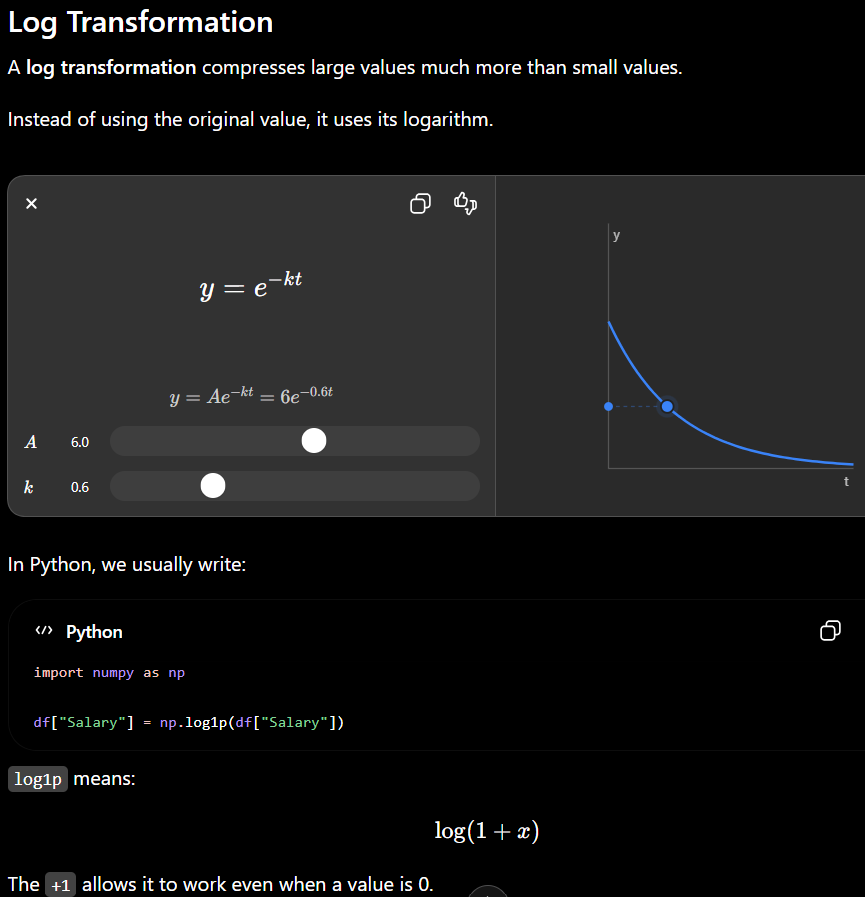

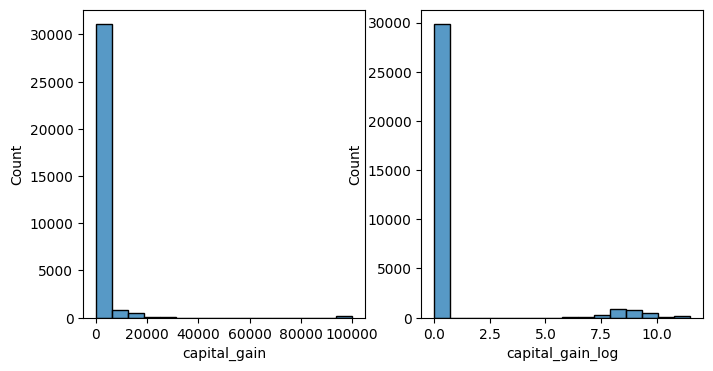

In [77]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.histplot(df["capital_gain"])

plt.subplot(1,2,2)
sns.histplot(df["capital_gain_log"])

plt.show()

The histogram after log transformation is more evenly distributed than the original feature, indicating reduced skewness and making it more suitable for machine learning algorithms.

####conclusion
In this assignment, missing values were handled using the mode for categorical features.

Standard Scaling and Min-Max Scaling were applied to numerical features, and their appropriate use cases were discussed.

 One-Hot Encoding and Label Encoding were performed on categorical variables based on the number of unique categories.

 Two new features were created to improve the information available to the model, and a log transformation was applied to a skewed feature to reduce skewness and improve data distribution. These preprocessing techniques help improve the performance and reliability of machine learning models.

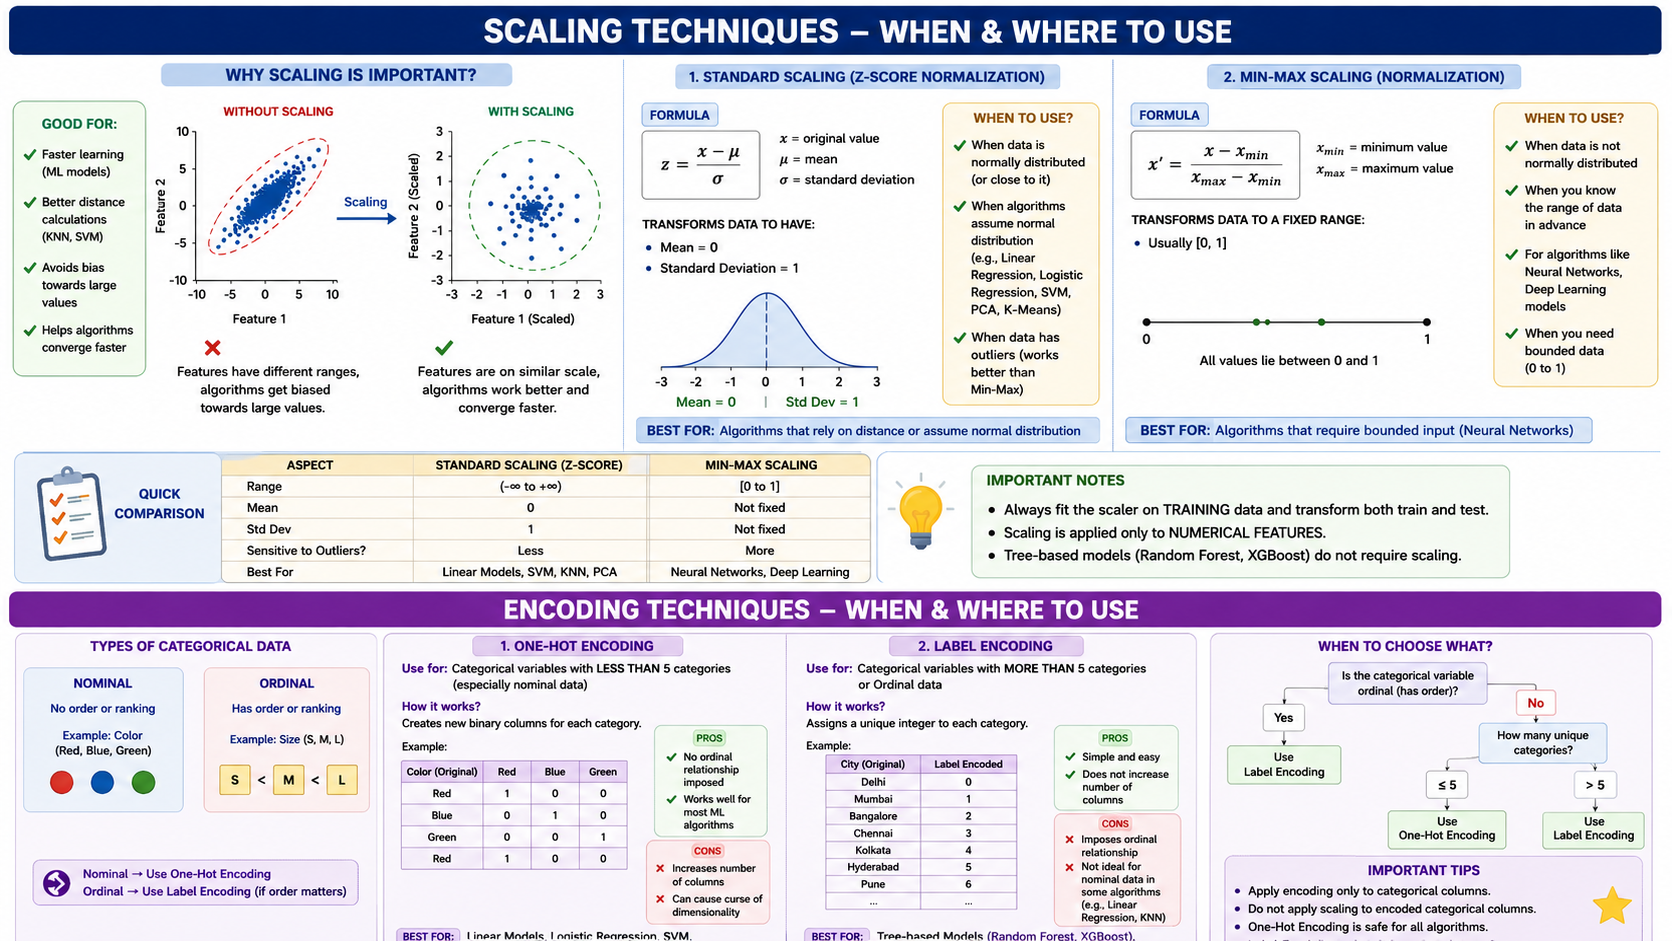